# Model Comparison: Pangu-Weather 6h vs Aurora vs Stormer

Сравнение трёх transformer-based моделей погоды по результатам 96-init кампании (2024-2025, 4 инициализации
в месяц, 6h-шаги до +48h): **RMSE** и **ACC** (anomaly correlation coefficient) против ERA5 ground truth.

**Важно**: Stormer работает на грубой сетке 1.40625° (128×256), не 0.25° (721×1440) как Pangu/Aurora — его
ACC не сравнивается напрямую (грубая сетка сглаживает мелкомасштабный шум, завышая ACC — задокументировано
в `run_campaign_stormer.py`). RMSE у всех трёх — в физических единицах, сравнение корректно.


In [1]:
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 110

MODELS = ['pangu6', 'aurora', 'stormer']
MODEL_LABELS = {'pangu6': 'Pangu-Weather (6h)', 'aurora': 'Aurora', 'stormer': 'Stormer'}
MODEL_COLORS = {'pangu6': '#2980b9', 'aurora': '#c0392b', 'stormer': '#27ae60'}
RESULTS_ROOT = os.path.expanduser('~/weather-interpretability/results')


## 1. Загрузка всех результатов кампании


In [2]:
all_runs = {}
for model in MODELS:
    files = sorted(glob.glob(os.path.join(RESULTS_ROOT, f'campaign_{model}', '*.pkl')))
    runs = []
    for fpath in files:
        with open(fpath, 'rb') as f:
            runs.append(pickle.load(f))
    all_runs[model] = runs
    print(f'{model}: {len(runs)} init runs loaded')


pangu6: 96 init runs loaded
aurora: 95 init runs loaded
stormer: 96 init runs loaded


## 2. Агрегация: среднее RMSE/ACC по всем init датам, для каждого lead time


In [3]:
def aggregate_metric(runs, metric_key, variable):
    """Average a metric across all init dates, indexed by lead_hours."""
    by_lead = {}
    for run in runs:
        for lead, step_metrics in zip(run['lead_hours'], run[metric_key]):
            if variable in step_metrics:
                by_lead.setdefault(lead, []).append(step_metrics[variable])
    leads = sorted(by_lead.keys())
    means = [np.mean(by_lead[l]) for l in leads]
    return leads, means


VARIABLES_TO_PLOT = [
    ('mean_sea_level_pressure', 'MSLP'),
    ('2m_temperature', 'T2M'),
    ('geopotential@500hPa', 'Z@500hPa'),
    ('u_component_of_wind@250hPa', 'U@250hPa'),
]


## 3. RMSE vs lead time — 3-way сравнение


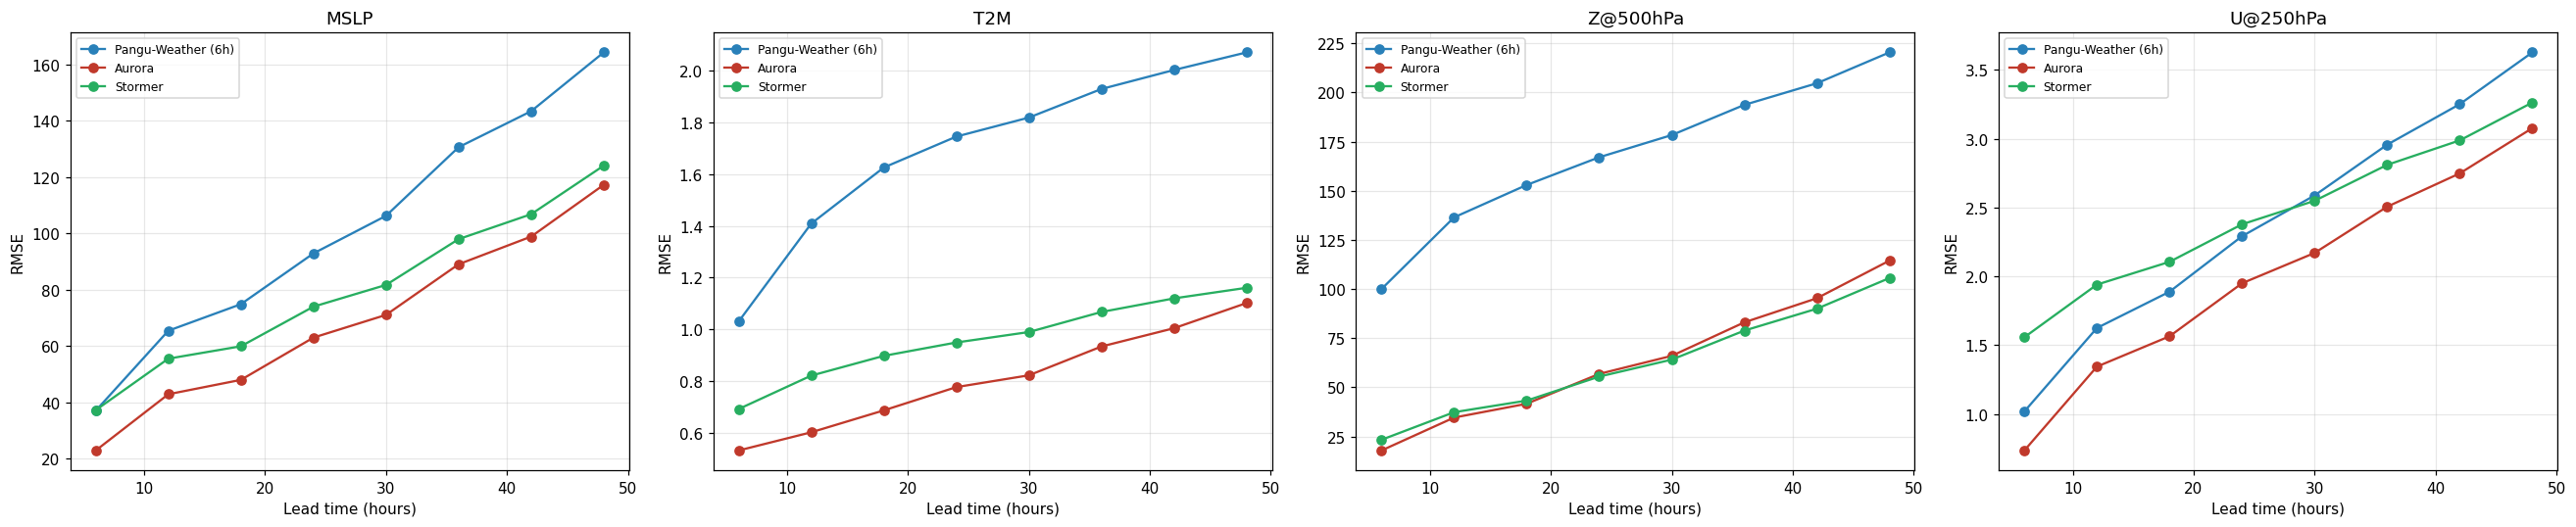

In [4]:
fig, axes = plt.subplots(1, len(VARIABLES_TO_PLOT), figsize=(6 * len(VARIABLES_TO_PLOT), 5))
for ax, (var_key, var_label) in zip(axes, VARIABLES_TO_PLOT):
    for model in MODELS:
        leads, means = aggregate_metric(all_runs[model], 'rmse', var_key)
        ax.plot(leads, means, marker='o', label=MODEL_LABELS[model], color=MODEL_COLORS[model])
    ax.set_xlabel('Lead time (hours)')
    ax.set_ylabel('RMSE')
    ax.set_title(var_label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('figures/05_model_comparison', exist_ok=True)
plt.savefig('figures/05_model_comparison/rmse_vs_leadtime.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. ACC vs lead time

Stormer помечен пунктиром и отдельной аннотацией — его ACC систематически завышен из-за грубого разрешения
(1.40625° vs 0.25°), не сравнивать напрямую со значениями Pangu/Aurora как показатель "лучше/хуже".


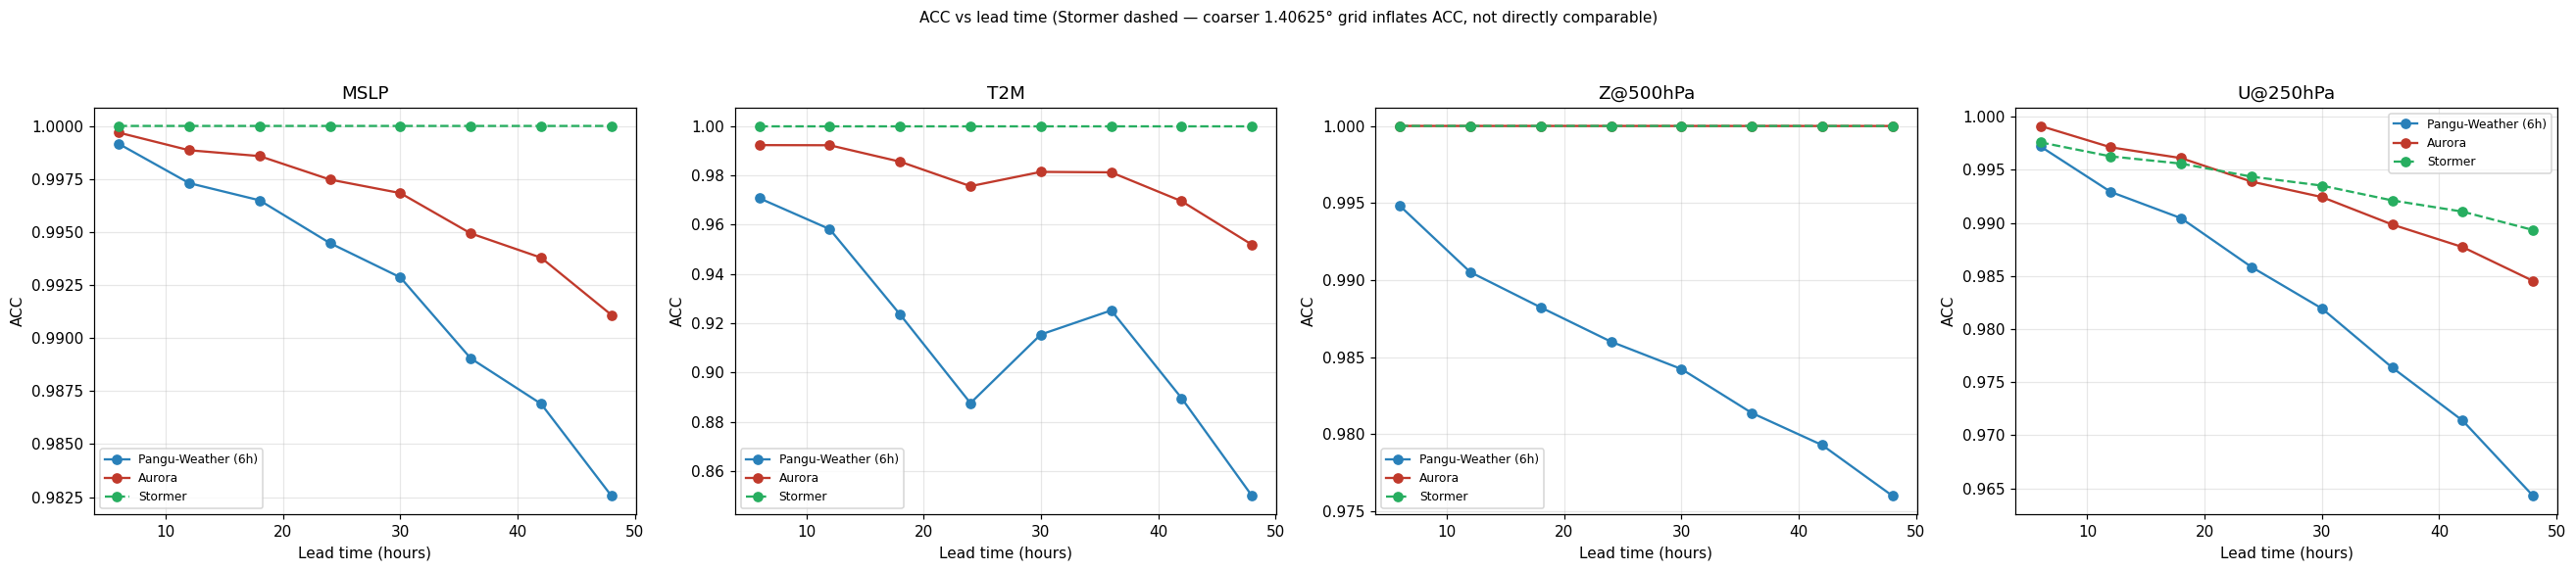

In [5]:
fig, axes = plt.subplots(1, len(VARIABLES_TO_PLOT), figsize=(6 * len(VARIABLES_TO_PLOT), 5))
for ax, (var_key, var_label) in zip(axes, VARIABLES_TO_PLOT):
    for model in MODELS:
        leads, means = aggregate_metric(all_runs[model], 'acc', var_key)
        linestyle = '--' if model == 'stormer' else '-'
        ax.plot(leads, means, marker='o', linestyle=linestyle, label=MODEL_LABELS[model], color=MODEL_COLORS[model])
    ax.set_xlabel('Lead time (hours)')
    ax.set_ylabel('ACC')
    ax.set_title(var_label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('ACC vs lead time (Stormer dashed — coarser 1.40625° grid inflates ACC, not directly comparable)',
             y=1.05, fontsize=10)
plt.tight_layout()
plt.savefig('figures/05_model_comparison/acc_vs_leadtime.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Наблюдения

*(Заполнить после просмотра: какая модель точнее на каких переменных/lead time, растёт ли разрыв между моделями
с ростом lead time, согласуется ли с ожиданиями архитектур.)*
